In [1]:
from tslearn.clustering import TimeSeriesKMeans
from tslearn.clustering import KernelKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

import pandas as pd
import numpy as np
import sklearn.preprocessing
import matplotlib.pyplot as plt

from modules import ForecastingModel
from modules import YfScrapper

In [11]:
N_CLUSTERS = 2

# Stock price data

In [12]:
model = ForecastingModel(
    price_type="Close",
    time_period="5y",
    time_interval="1wk"
)

# Input file with a list of portfolio tickers
input_tickers = pd.read_csv('portfolio_tickers.csv')  
tickers = input_tickers['Tickers'].tolist()

In [35]:
df_list = []
for ticker in tickers:
    data = model.get_stock_price(ticker)
    df_list.append(data)
    
X_train = pd.concat(df_list, axis=1)
X_train_scaled = sklearn.preprocessing.scale(X_train)
X_train_scaled = X_train_scaled.T
X_train_scaled = np.nan_to_num(X_train_scaled)
X_train_scaled.shape

(37, 262)

In [21]:
ts_kmeans_model = TimeSeriesKMeans(
    n_clusters=N_CLUSTERS,
    metric="dtw",
    max_iter=10,
    random_state=42
)
labels = ts_kmeans_model.fit_predict(X_train_scaled)
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [22]:
input_tickers['cluster'] = labels
input_tickers.groupby('cluster').count()

,Tickers
cluster,
0,21
1,16


Cluster 0
['ABNB', 'SE', 'TEAM', 'SNOW', 'NET', 'DOCN', 'U', 'SEMR', 'LMND', 'ZM', 'PINS', 'MRNA', 'ROKU', 'GLBE', 'ASAN', 'UPST', 'TWLO', 'CRSP', 'APPN', 'NNOX', 'SHOP']
Cluster 1
['TSLA', 'TTD', 'NVDA', 'GOOG', 'CRWD', 'AMZN', 'IDXX', 'MELI', 'ZS', 'ASML', 'AXON', 'LULU', 'HUBS', 'DDOG', 'CDNS', 'MDB']


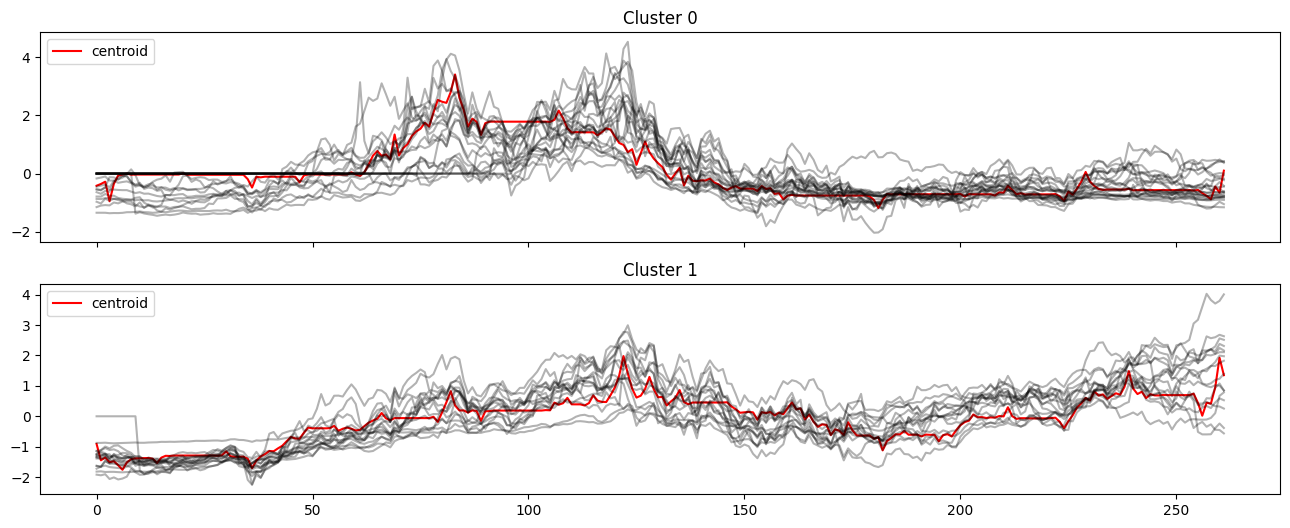

In [34]:
fig, axes = plt.subplots(
    nrows=N_CLUSTERS,
    ncols=1,
    figsize=(16, 6),
    sharex=True
)
for idx, cluster in enumerate(ts_kmeans_model.cluster_centers_):
    axes[idx].set_title(f"Cluster {idx}")
    axes[idx].plot(cluster, c='red', label="centroid")
    for ticker_series in X_train[np.where(labels==idx)]:
        axes[idx].plot(
            ticker_series, 
            c='black',
            alpha=0.3
        )
    axes[idx].legend(loc='upper left')
    print(f"Cluster {idx}")
    print([ticker for ticker in input_tickers[input_tickers['cluster']==idx]['Tickers'].to_list()])


# Kernel method from tslearn

In [50]:
# X_train_ts_scaled = TimeSeriesScalerMeanVariance().fit_transform(X_train)
# X_train_ts_scaled = X_train_ts_scaled.T
# X_train_ts_scaled = np.nan_to_num(X_train_ts_scaled)

gak_km = KernelKMeans(n_clusters=N_CLUSTERS,
                      kernel="gak",
                      kernel_params={"sigma": "auto"},
                      n_init=20,
                      verbose=True,
                      random_state=42)
labels = gak_km.fit_predict(X_train_scaled)
labels


/Users/sienlong/personal/financial_analysis_forecasting/.venv/lib/python3.11/site-packages/tslearn/utils/utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 37 1-dimensional timeseries
  warnings.warn(
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.4s


Init 1
54.236 --> 51.965 --> 51.965 --> 
Init 2
54.922 --> 50.300 --> 47.392 --> 45.485 --> 45.485 --> 
Init 3
54.863 --> 47.874 --> 45.808 --> 45.326 --> 45.326 --> 
Init 4
54.953 --> 49.417 --> 46.986 --> 46.104 --> 45.326 --> 45.326 --> 
Init 5
54.724 --> 52.363 --> 51.570 --> 49.152 --> 46.313 --> 45.326 --> 45.326 --> 
Init 6
55.223 --> 50.704 --> 47.347 --> 45.808 --> 45.326 --> 45.326 --> 
Init 7
55.236 --> 47.735 --> 45.720 --> 45.485 --> 45.485 --> 
Init 8
54.568 --> 46.328 --> 45.485 --> 45.485 --> 
Init 9
55.695 --> 54.226 --> 48.606 --> 45.326 --> 45.326 --> 
Init 10
55.664 --> 50.893 --> 47.366 --> 46.088 --> 45.720 --> 45.485 --> 45.485 --> 
Init 11
54.739 --> 48.814 --> 47.794 --> 46.346 --> 45.326 --> 45.326 --> 
Init 12
54.916 --> 48.236 --> 45.966 --> 45.485 --> 45.485 --> 
Init 13
55.271 --> 52.710 --> 49.583 --> 46.790 --> 45.326 --> 45.326 --> 
Init 14
54.845 --> 52.178 --> 51.003 --> 50.778 --> 50.043 --> 47.208 --> 45.485 --> 45.485 --> 
Init 15
54.903 --> 47.230

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [51]:
input_tickers['cluster_kernel'] = labels
input_tickers.groupby('cluster_kernel').count()

,Tickers,cluster
cluster_kernel,,
0,19,19
1,18,18


Cluster 0
['TSLA', 'TTD', 'NVDA', 'GOOG', 'CRWD', 'AMZN', 'IDXX', 'MELI', 'ZS', 'ASML', 'AXON', 'TEAM', 'LULU', 'NET', 'HUBS', 'DDOG', 'CDNS', 'MDB', 'MRNA']
Cluster 1
['ABNB', 'SE', 'SNOW', 'DOCN', 'U', 'SEMR', 'LMND', 'ZM', 'PINS', 'ROKU', 'GLBE', 'ASAN', 'UPST', 'TWLO', 'CRSP', 'APPN', 'NNOX', 'SHOP']


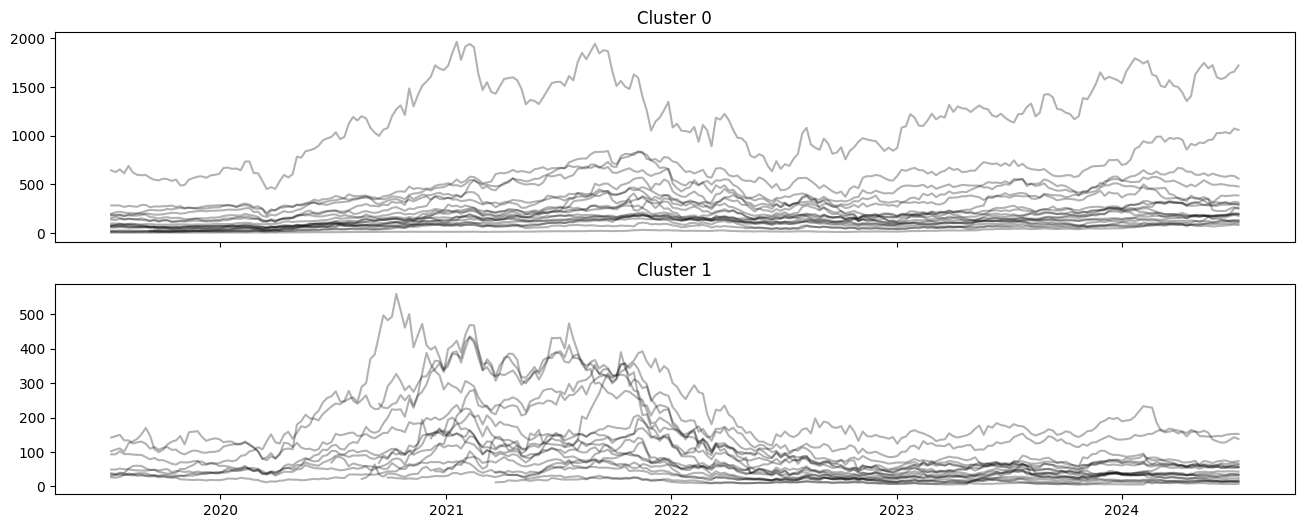

In [81]:
fig, axes = plt.subplots(
    nrows=N_CLUSTERS,
    ncols=1,
    figsize=(16, 6),
    sharex=True
)
for idx in range(N_CLUSTERS):
    axes[idx].set_title(f"Cluster {idx}")
    for col_name, ticker_series in X_train.iloc[:, np.where(labels==idx)[0]].items():
        axes[idx].plot(
            ticker_series, 
            c='black',
            alpha=0.3
        )
    print(f"Cluster {idx}")
    print([ticker for ticker in input_tickers[input_tickers['cluster_kernel']==idx]['Tickers'].to_list()])
